# DBSCAN：非凸簇识别、参数选择与噪声诊断

本实验用带噪声的双弯月数据展示完整的 DBSCAN 分析流程：

1. 检查数据并进行尺度标准化；
2. 选择 $\varepsilon$ 与 `MinPts`；
3. 区分核心点、边界点和噪声点，并汇总最终簇；
4. 用内部指标、外部指标和噪声识别指标评价结果；

最后将结果与 K-means 对照，说明密度聚类对非凸结构的优势。

In [1]:
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib
configure_matplotlib()
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
SINGLE_FIGSIZE = (8, 5.5)
COLORS = ["#4C78A8", "#F28E2B", "#59A14F", "#B279A2"]
RANDOM_STATE = 42

## 1. 构造含离群点的非凸数据

主体样本由两个相互嵌套的弯月形簇组成，再加入均匀分布的人工噪声。这样的数据不满足近似球形簇假设，适合检验 DBSCAN 的密度连通能力。

,value
total samples,565
signal samples,520
injected noise,45
features,2


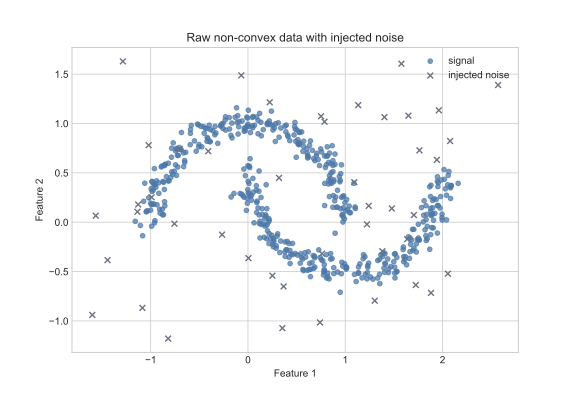

In [2]:
X_signal, y_signal = make_moons(
    n_samples=520, noise=0.075, random_state=RANDOM_STATE
)
rng = np.random.default_rng(RANDOM_STATE)
X_noise = rng.uniform(low=[-1.7, -1.2], high=[2.7, 1.7], size=(45, 2))
X = np.vstack([X_signal, X_noise])
y_true = np.concatenate([y_signal, np.full(len(X_noise), -1)])

data_summary = pd.DataFrame(
    {
        "quantity": [len(X), len(X_signal), len(X_noise), X.shape[1]],
        "value": [len(X), len(X_signal), len(X_noise), X.shape[1]],
    },
    index=["total samples", "signal samples", "injected noise", "features"],
)[["value"]]
display(data_summary)

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE)
ax.scatter(X_signal[:, 0], X_signal[:, 1], s=22, alpha=0.72, color="#4C78A8", label="signal")
ax.scatter(X_noise[:, 0], X_noise[:, 1], s=34, marker="x", linewidth=1.4, color="#6B7280", label="injected noise")
ax.set(title="Raw non-convex data with injected noise", xlabel="Feature 1", ylabel="Feature 2")
ax.legend()
plt.show()

## 2. 标准化与 $k$-distance 诊断

先将每个特征标准化。取 `MinPts = 4`，再计算每个样本到第 4 个近邻的距离。绘制 $k$-distance 曲线来选择 $\varepsilon$。

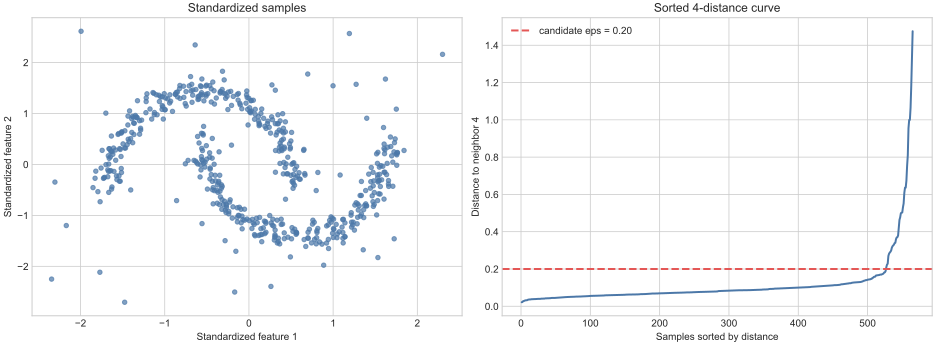

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
min_samples = 4
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])
chosen_eps = 0.20

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], s=20, alpha=0.7, color="#4C78A8")
axes[0].set(title="Standardized samples", xlabel="Standardized feature 1", ylabel="Standardized feature 2")
axes[1].plot(np.arange(1, len(k_distances) + 1), k_distances, color="#4C78A8", linewidth=2)
axes[1].axhline(chosen_eps, color="#E45756", linestyle="--", linewidth=2, label=f"candidate eps = {chosen_eps:.2f}")
axes[1].set(title=f"Sorted {min_samples}-distance curve", xlabel="Samples sorted by distance", ylabel=f"Distance to neighbor {min_samples}")
axes[1].legend()
plt.show()

## 3. 拟合最终模型并区分点类型

`core_sample_indices_` 给出核心点。获得簇标签但不在该集合中的样本是边界点；标签为 $-1$ 的样本是噪声点。下图同时呈现最终簇、三类点以及一个核心点的 $\varepsilon$-邻域。

,count
point type,
core,526
noise,34
border,5


,samples
cluster,
0,264
1,267


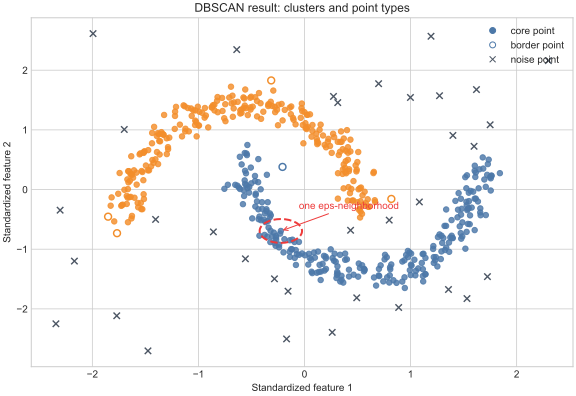

In [4]:
dbscan = DBSCAN(eps=chosen_eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)
core_mask = np.zeros(len(X_scaled), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
noise_mask = labels == -1
border_mask = (~core_mask) & (~noise_mask)
cluster_ids = sorted(set(labels) - {-1})

type_summary = pd.Series(
    np.select(
        [core_mask, border_mask, noise_mask],
        ["core", "border", "noise"],
        default="unknown",
    ),
    name="point_type",
).value_counts().rename_axis("point type").to_frame("count")
cluster_summary = pd.Series(labels[~noise_mask]).value_counts().sort_index().rename_axis("cluster").to_frame("samples")
display(type_summary)
display(cluster_summary)

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE, constrained_layout=True)
for cluster_id in cluster_ids:
    cluster_color = COLORS[cluster_id % len(COLORS)]
    cluster_core = (labels == cluster_id) & core_mask
    cluster_border = (labels == cluster_id) & border_mask
    ax.scatter(X_scaled[cluster_core, 0], X_scaled[cluster_core, 1], s=30, color=cluster_color, alpha=0.82)
    ax.scatter(X_scaled[cluster_border, 0], X_scaled[cluster_border, 1], s=48, facecolors="none", edgecolors=cluster_color, linewidth=1.5)
ax.scatter(X_scaled[noise_mask, 0], X_scaled[noise_mask, 1], s=42, marker="x", color="#4B5563", linewidth=1.4)
reference_index = dbscan.core_sample_indices_[len(dbscan.core_sample_indices_) // 3]
reference_point = X_scaled[reference_index]
ax.add_patch(Circle(reference_point, chosen_eps, fill=False, linestyle="--", linewidth=2, edgecolor="#ed3a3a"))
ax.annotate("one eps-neighborhood", reference_point, xytext=(18, 22), textcoords="offset points", color="#ed3a3a", arrowprops={"arrowstyle": "->", "color": "#ed3a3a"})
legend_items = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#4C78A8", markeredgecolor="#4C78A8", label="core point"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor="#4C78A8", label="border point"),
    Line2D([0], [0], marker="x", color="#4B5563", linestyle="none", label="noise point"),
]
ax.legend(handles=legend_items, loc="upper right")
ax.set(title="DBSCAN result: clusters and point types", xlabel="Standardized feature 1", ylabel="Standardized feature 2")
plt.show()

## 4. 评价聚类与噪声识别

使用 Silhouette 和 ARI 进行模型评价。

In [5]:
true_noise = y_true == -1
true_positive_noise = np.sum(noise_mask & true_noise)
noise_precision = true_positive_noise / max(noise_mask.sum(), 1)
noise_recall = true_positive_noise / true_noise.sum()
non_noise = ~noise_mask
evaluation = pd.Series(
    {
        "clusters": len(cluster_ids),
        "noise samples": int(noise_mask.sum()),
        "noise rate": noise_mask.mean(),
        "silhouette (non-noise)": silhouette_score(X_scaled[non_noise], labels[non_noise]),
        "ARI (all samples)": adjusted_rand_score(y_true, labels),
        "noise precision": noise_precision,
        "noise recall": noise_recall,
    },
    name="value",
).to_frame()
evaluation.round(3)

,value
clusters,2.000
noise samples,34.000
noise rate,0.060
silhouette (non-noise),0.376
ARI (all samples),0.944
noise precision,0.941
noise recall,0.711


## 5. 与 K-means 对照


,DBSCAN,K-means
ARI,0.944,0.400
Silhouette on assigned samples,0.376,0.472
noise samples,34.000,0.000


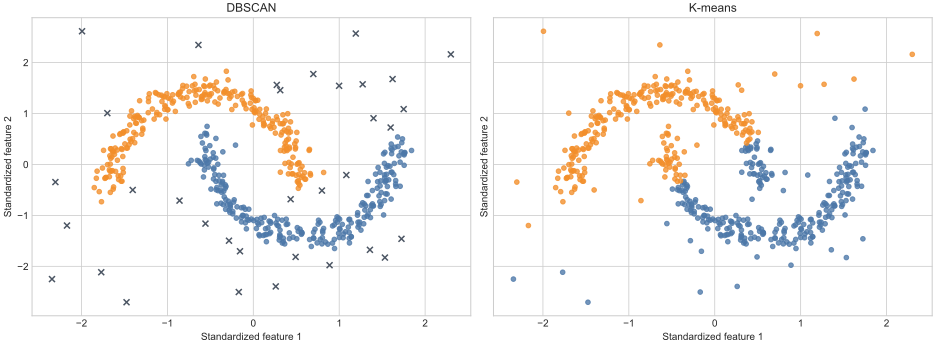

In [6]:
kmeans_labels = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit_predict(X_scaled)
comparison = pd.DataFrame(
    {
        "DBSCAN": [adjusted_rand_score(y_true, labels), silhouette_score(X_scaled[non_noise], labels[non_noise]), int(noise_mask.sum())],
        "K-means": [adjusted_rand_score(y_true, kmeans_labels), silhouette_score(X_scaled, kmeans_labels), 0],
    },
    index=["ARI", "Silhouette on assigned samples", "noise samples"],
)
display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True, constrained_layout=True)
for cluster_id in cluster_ids:
    mask = labels == cluster_id
    axes[0].scatter(X_scaled[mask, 0], X_scaled[mask, 1], s=22, alpha=0.78, color=COLORS[cluster_id])
axes[0].scatter(X_scaled[noise_mask, 0], X_scaled[noise_mask, 1], s=36, marker="x", color="#4B5563")
axes[0].set_title("DBSCAN")
for cluster_id in np.unique(kmeans_labels):
    mask = kmeans_labels == cluster_id
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1], s=22, alpha=0.78, color=COLORS[cluster_id])
axes[1].set_title("K-means")
for ax in axes:
    ax.set(xlabel="Standardized feature 1", ylabel="Standardized feature 2")
plt.show()

## 观察

DBSCAN 在这个问题下能更好的恢复类别。

注意 K-menas 的 Silhouette 值比 DBSCAN 高，这提示我们不止得看聚类指标的具体值，分析时也需要结合具体的聚类图形。